In [1]:
# Gavriel Blau

In [2]:
import pandas as pd

df = pd.read_csv("traffic_optimization.csv")

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("\nColumn Names:\n", df.columns.tolist())

print("\nMissing Values:\n", df.isna().sum())

if "incident_flag" in df.columns:
    print("\nIncident Flag Distribution:\n", df["incident_flag"].value_counts(normalize=True))

print("\nSummary Statistics:\n", df.describe().T)

if "rl_action" in df.columns:
    print("\nRL Action Distribution:\n", df["rl_action"].value_counts())

if "phase" in df.columns:
    print("\nTraffic Signal Phase Distribution:\n", df["phase"].value_counts())

print("\nChance accuracy for 8 actions =", 1/8)

Rows: 1000000
Columns: 22

Column Names:
 ['timestamp', 'intersection_id', 'phase', 'phase_duration_sec', 'veh_north_in', 'veh_south_in', 'veh_east_in', 'veh_west_in', 'queue_north', 'queue_south', 'queue_east', 'queue_west', 'avg_speed_kph', 'density_veh_per_km', 'pedestrian_count', 'incident_flag', 'rain_mm', 'temperature_c', 'is_rush_hour', 'rl_action', 'reward', 'cumulative_reward']

Missing Values:
 timestamp             0
intersection_id       0
phase                 0
phase_duration_sec    0
veh_north_in          0
veh_south_in          0
veh_east_in           0
veh_west_in           0
queue_north           0
queue_south           0
queue_east            0
queue_west            0
avg_speed_kph         0
density_veh_per_km    0
pedestrian_count      0
incident_flag         0
rain_mm               0
temperature_c         0
is_rush_hour          0
rl_action             0
reward                0
cumulative_reward     0
dtype: int64

Incident Flag Distribution:
 incident_flag
0    0.

In [3]:
# Drop likely leakage / non-modeling columns
drop_cols = ["timestamp", "intersection_id", "cumulative_reward", "reward"]
df_model = df.drop(columns=drop_cols)

# Stratified subsample for compute (25,000 rows per action -> 200,000 total)
rows_per_class = 25000

df_sampled = (
    df_model
    .groupby("rl_action", group_keys=False)
    .apply(lambda x: x.sample(n=rows_per_class, random_state=42))
)

print("Original rows:", len(df_model))
print("Sampled rows:", len(df_sampled))
print("\nAction distribution in sample:")
print(df_sampled["rl_action"].value_counts().sort_index())

Original rows: 1000000
Sampled rows: 200000

Action distribution in sample:
rl_action
0    25000
1    25000
2    25000
3    25000
4    25000
5    25000
6    25000
7    25000
Name: count, dtype: int64


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df_sampled.drop(columns=["rl_action"])
y = df_sampled["rl_action"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

rf_acc = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest accuracy:", rf_acc)

Training Random Forest...

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.12      0.12      0.12      5000
           1       0.13      0.13      0.13      5000
           2       0.13      0.12      0.13      5000
           3       0.13      0.13      0.13      5000
           4       0.12      0.13      0.13      5000
           5       0.13      0.13      0.13      5000
           6       0.12      0.12      0.12      5000
           7       0.12      0.11      0.12      5000

    accuracy                           0.13     40000
   macro avg       0.13      0.13      0.13     40000
weighted avg       0.13      0.13      0.13     40000


Confusion Matrix (Random Forest):
[[602 670 590 636 649 608 630 615]
 [631 657 590 636 672 615 639 560]
 [604 667 614 643 674 611 600 587]
 [620 642 591 664 686 630 627 540]
 [584 629 596 652 660 590 672 617]
 [602 650 571 670 636 654 625 592]
 [646 688 569 661 661 630 605 540]
 [6

In [5]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="uniform", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, y_pred_dummy)

print("Dummy (uniform) accuracy:", dummy_acc)

print("\nDummy classification report:")
print(classification_report(y_test, y_pred_dummy))

Dummy (uniform) accuracy: 0.1244

Dummy classification report:
              precision    recall  f1-score   support

           0       0.12      0.12      0.12      5000
           1       0.13      0.13      0.13      5000
           2       0.13      0.12      0.12      5000
           3       0.13      0.13      0.13      5000
           4       0.12      0.13      0.13      5000
           5       0.12      0.12      0.12      5000
           6       0.13      0.13      0.13      5000
           7       0.12      0.12      0.12      5000

    accuracy                           0.12     40000
   macro avg       0.12      0.12      0.12     40000
weighted avg       0.12      0.12      0.12     40000



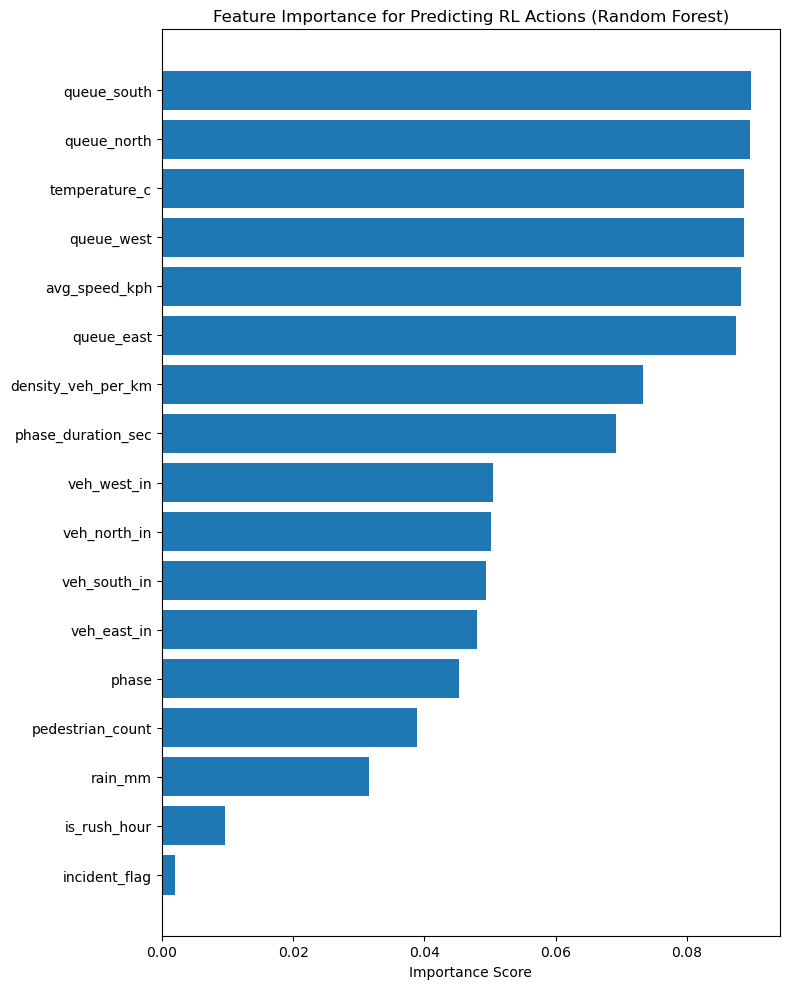

In [6]:
importances = model.feature_importances_
feature_names = X_train.columns
sorted_idx = importances.argsort()

plt.figure(figsize=(8, 10))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance for Predicting RL Actions (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

df_temp = df_sampled.copy()

lag_features = [
    "queue_north", "queue_south", "queue_east", "queue_west",
    "avg_speed_kph", "phase", "phase_duration_sec"
]

for col in lag_features:
    if col in df_temp.columns:
        df_temp[f"{col}_lag1"] = df_temp[col].shift(1)

# Drop NA rows created by lagging
df_temp = df_temp.dropna().reset_index(drop=True)

print("Shape after adding lag features:", df_temp.shape)

Shape after adding lag features: (199999, 25)


In [8]:
X2 = df_temp.drop(columns=["rl_action"])
y2 = df_temp["rl_action"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

print("Training Gradient Boosting with temporal features...")
gb_model.fit(X2_train, y2_train)

y_pred_gb = gb_model.predict(X2_test)
gb_acc = accuracy_score(y2_test, y_pred_gb)

print("\nClassification Report (GB + lags):")
print(classification_report(y2_test, y_pred_gb))

print("\nGradient Boosting accuracy (with lags):", gb_acc)

Training Gradient Boosting with temporal features...

Classification Report (GB + lags):
              precision    recall  f1-score   support

           0       0.12      0.12      0.12      5000
           1       0.13      0.14      0.14      5000
           2       0.13      0.12      0.13      5000
           3       0.13      0.13      0.13      5000
           4       0.13      0.13      0.13      5000
           5       0.13      0.14      0.13      5000
           6       0.11      0.10      0.10      5000
           7       0.13      0.13      0.13      5000

    accuracy                           0.13     40000
   macro avg       0.13      0.13      0.13     40000
weighted avg       0.13      0.13      0.13     40000


Gradient Boosting accuracy (with lags): 0.126325


In [9]:
print("\nMODEL COMPARISON (Accuracy)")
print(f"Random Forest (no lags): {rf_acc:.4f}")
print(f"Dummy baseline:          {dummy_acc:.4f}")
print(f"GB + lag features:       {gb_acc:.4f}")

print("\nNotes:")
print("- Chance accuracy for 8 classes is ~0.125.")
print("- Improvements (if any) suggest temporal dependence; no improvement suggests missing context/internal state.")


MODEL COMPARISON (Accuracy)
Random Forest (no lags): 0.1254
Dummy baseline:          0.1244
GB + lag features:       0.1263

Notes:
- Chance accuracy for 8 classes is ~0.125.
- Improvements (if any) suggest temporal dependence; no improvement suggests missing context/internal state.


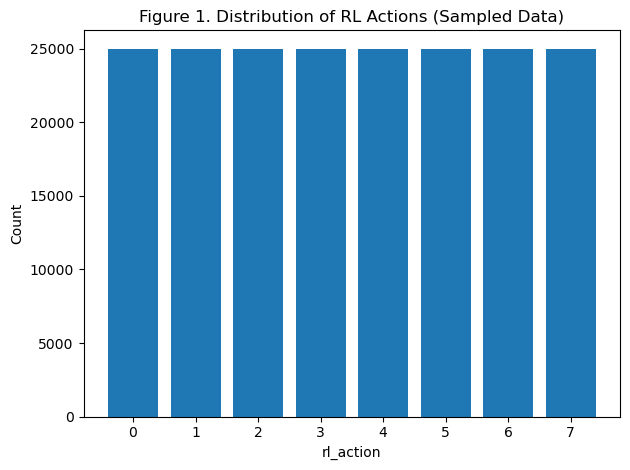

In [10]:
plt.figure()
counts = df_sampled["rl_action"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Figure 1. Distribution of RL Actions (Sampled Data)")
plt.xlabel("rl_action")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Figure1_Action_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

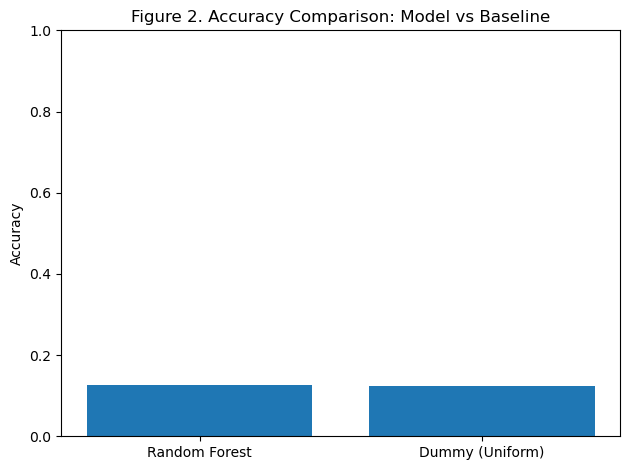

In [11]:
plt.figure()
names = ["Random Forest", "Dummy (Uniform)"]
vals = [rf_acc, dummy_acc]
plt.bar(names, vals)
plt.title("Figure 2. Accuracy Comparison: Model vs Baseline")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("Figure2_Accuracy_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

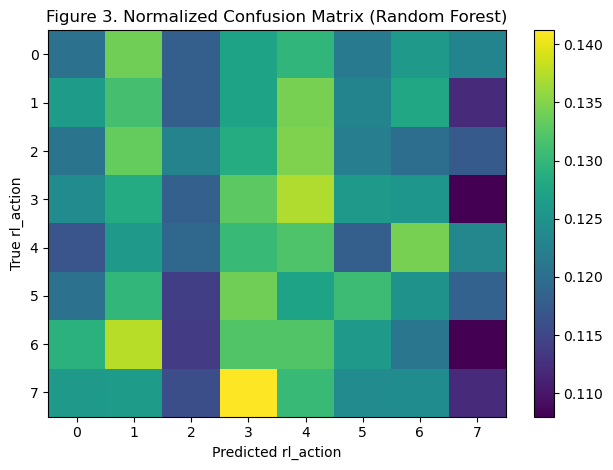

In [12]:
labels = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=labels).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure()
plt.imshow(cm_norm, aspect="auto")
plt.title("Figure 3. Normalized Confusion Matrix (Random Forest)")
plt.xlabel("Predicted rl_action")
plt.ylabel("True rl_action")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.savefig("Figure3_Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

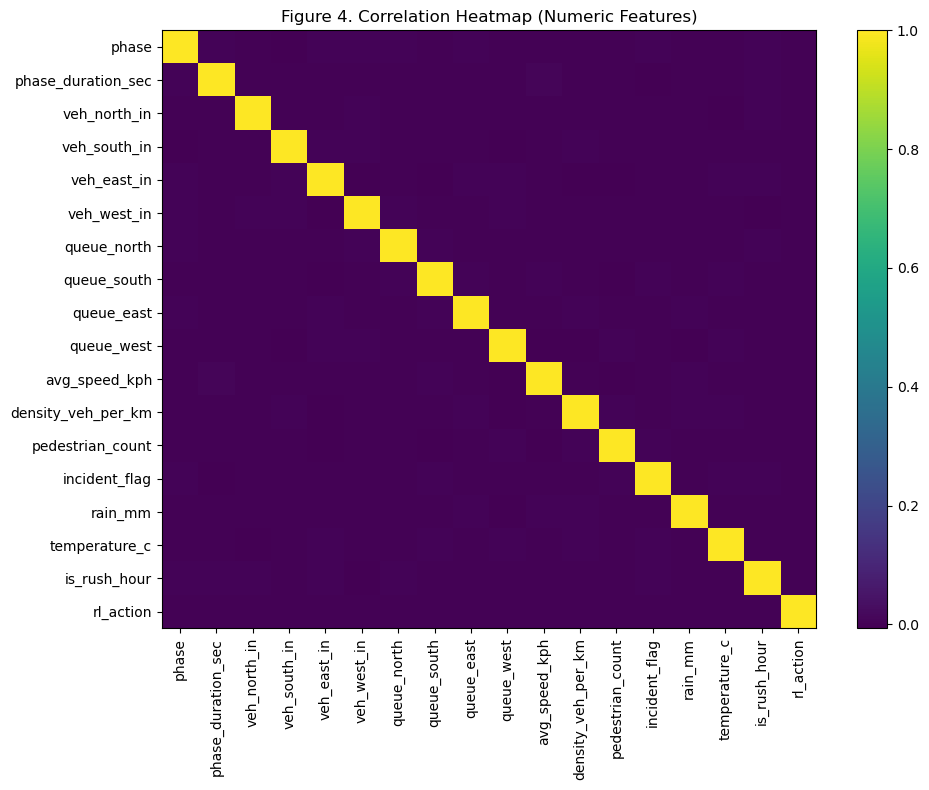

In [13]:
corr = df_sampled.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.title("Figure 4. Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.savefig("Figure4_Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()